In [1]:
from google.colab import files
uploaded = files.upload()

Saving clean_with_names.csv to clean_with_names.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving ml_ready_data.csv to ml_ready_data.csv


In [3]:
##Question8
#Q8. Create a new categorical column planet_size_class using planet radius ranges
 #(Sub■Earth, Super■Earth, Neptune■like, Gas Giant).
 #Count planets in each category and visualize using a pie chart.


import pandas as pd
import numpy as np

df = pd.read_csv("ml_ready_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (6155, 20)


,disc_year,pl_orbper,pl_rade,pl_eqt,st_teff,st_rad,st_mass,sy_dist,disc_facility_HATSouth,disc_facility_K2,disc_facility_KMTNet,disc_facility_Kepler,disc_facility_La Silla Observatory,disc_facility_Multiple Observatories,disc_facility_OGLE,disc_facility_Other,disc_facility_SuperWASP,disc_facility_Transiting Exoplanet Survey Satellite (TESS),disc_facility_W. M. Keck Observatory,disc_method
0,-2.011602,-0.013504,-0.051325,-0.178103,-0.362500,4.143826,4.293438,-0.509860,0,0,0,0,0,0,0,1,0,0,0,Radial Velocity
1,-1.609419,-0.013467,-0.051325,-0.178103,-0.682050,7.070385,2.236798,-0.483311,0,0,0,0,0,0,0,1,0,0,0,Radial Velocity
2,-1.810511,-0.013531,-0.051325,-0.178103,-0.336948,2.728375,2.185382,-0.524520,0,0,0,0,0,0,0,1,0,0,0,Radial Velocity
3,-3.017060,-0.013223,-0.051325,-0.178103,-0.068219,-0.121708,-0.051215,-0.572028,0,0,0,0,0,0,0,0,0,0,1,Radial Velocity
4,-4.223610,-0.013411,-0.051325,-0.178103,0.202049,-0.084504,0.180157,-0.569379,0,0,0,0,0,1,0,0,0,0,0,Radial Velocity


In [4]:
conditions = [
    (df['pl_rade'] < 1),
    (df['pl_rade'] >= 1) & (df['pl_rade'] < 2),
    (df['pl_rade'] >= 2) & (df['pl_rade'] < 6),
    (df['pl_rade'] >= 6)
]

labels = ['Sub-Earth', 'Super-Earth', 'Neptune-like', 'Gas Giant']

df['planet_size_class'] = np.select(conditions, labels, default='Unknown')

size_counts = df['planet_size_class'].value_counts()
size_counts

,count
planet_size_class,
Sub-Earth,6147
Super-Earth,5
Gas Giant,2
Neptune-like,1


/tmp/ipykernel_1463/278052350.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


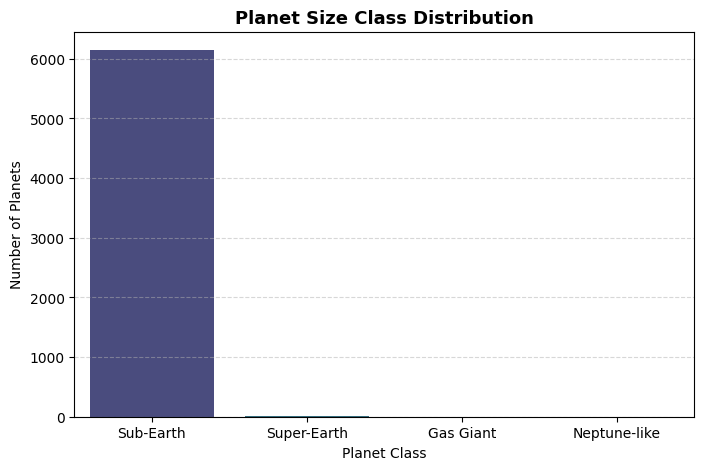

In [6]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x=size_counts.index,
    y=size_counts.values,
    palette="viridis"
)

plt.title("Planet Size Class Distribution", fontsize=13, fontweight='bold')
plt.xlabel("Planet Class")
plt.ylabel("Number of Planets")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [10]:
# Total counts
total_counts = size_counts

# Major class (Sub-Earth)
major = total_counts[['Sub-Earth']]

# Other small classes combined
other = total_counts.drop('Sub-Earth')

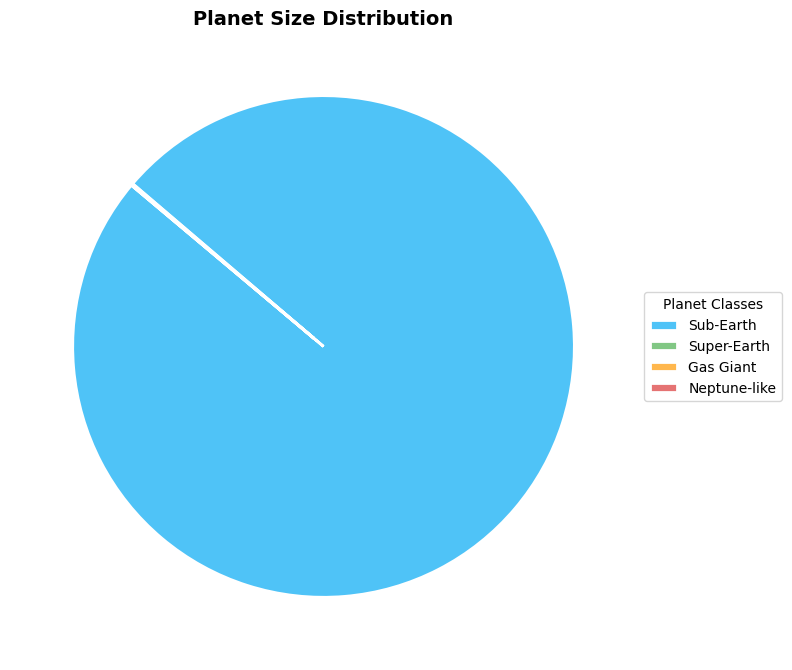

In [12]:
import matplotlib.pyplot as plt

labels = size_counts.index
values = size_counts.values

colors = ['#4FC3F7', '#81C784', '#FFB74D', '#E57373']

# explode small categories slightly so they are visible
explode = [0.05 if v < max(values)*0.1 else 0 for v in values]

plt.figure(figsize=(8,8))

plt.pie(
    values,
    colors=colors,
    startangle=140,
    explode=explode,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Legend instead of overlapping labels
plt.legend(labels, title="Planet Classes", loc="center left", bbox_to_anchor=(1, 0.5))

plt.title("Planet Size Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

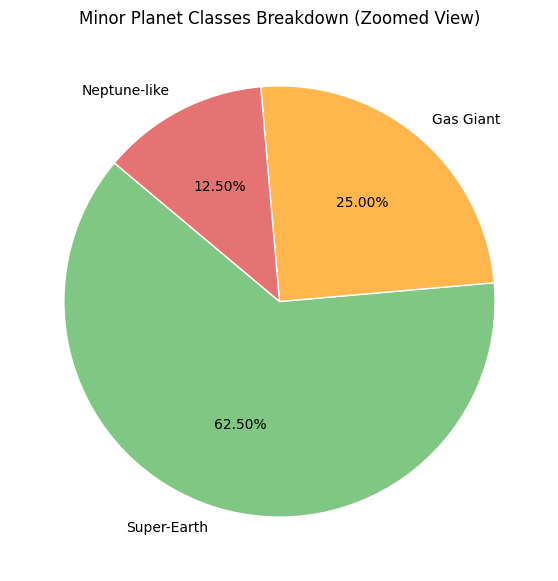

In [13]:
plt.figure(figsize=(7,7))

other_colors = ['#81C784', '#FFB74D', '#E57373']

plt.pie(
    other.values,
    labels=other.index,
    autopct='%1.2f%%',
    startangle=140,
    colors=other_colors,
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Minor Planet Classes Breakdown (Zoomed View)")
plt.show()

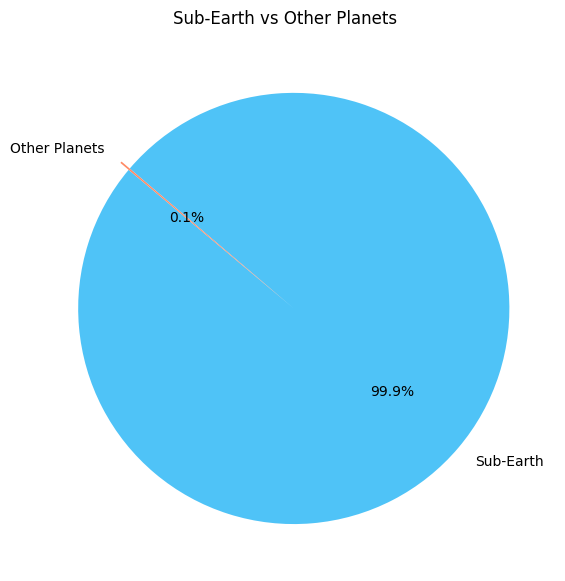

In [14]:
plt.figure(figsize=(7,7))

labels = ['Sub-Earth', 'Other Planets']
values = [major.values[0], other.values.sum()]

colors = ['#4FC3F7', '#FF8A65']

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=[0.05, 0]
)

plt.title("Sub-Earth vs Other Planets")
plt.show()